In [17]:
%%loadFromPOM

<dependency>
    <groupId>tech.tablesaw</groupId>
    <artifactId>tablesaw-core</artifactId>
    <version>0.43.1</version>
</dependency>

<dependency>
    <groupId>org.slf4j</groupId>
    <artifactId>slf4j-simple</artifactId>
    <version>1.7.25</version>
</dependency>

<dependency>
    <groupId>org.knowm.xchart</groupId>
    <artifactId>xchart</artifactId>
    <version>3.8.8</version>
</dependency>

# Primeros Pasos en analisis de datos en java

In [18]:
import tech.tablesaw.api.*;
import tech.tablesaw.io.csv.CsvReadOptions;

In [19]:
import java.nio.file.*;

Path entrada = Paths.get(
    "/workspaces/Ordenamiento-Manejo-de-colisiones-y-an-lisis-de-datos-en-Java/TMDB_movie_dataset_v11.csv");

Path salida = Paths.get(
    "/workspaces/Ordenamiento-Manejo-de-colisiones-y-an-lisis-de-datos-en-Java/TMDB_100k.csv");

Files.write(
    salida,
    Files.lines(entrada)
         .limit(100001) // cabecera + 100000 filas
         .toList()
);

/workspaces/Ordenamiento-Manejo-de-colisiones-y-an-lisis-de-datos-en-Java/TMDB_100k.csv

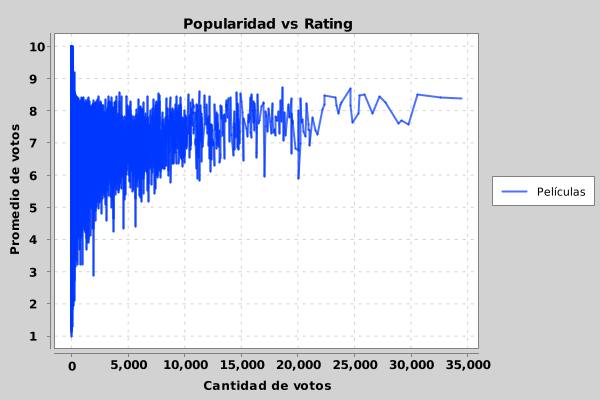

In [30]:
import tech.tablesaw.api.*;
import org.knowm.xchart.*;

Table peliculas = Table.read().csv("/workspaces/Ordenamiento-Manejo-de-colisiones-y-an-lisis-de-datos-en-Java/TMDB_100k.csv");

// Sacamos columnas numéricas
double[] xData = peliculas.numberColumn("vote_count").asDoubleArray();
double[] yData = peliculas.numberColumn("vote_average").asDoubleArray();

// Crear gráfico
XYChart chart = QuickChart.getChart(
    "Popularidad vs Rating",
    "Cantidad de votos",
    "Promedio de votos",
    "Películas",
    xData,
    yData
);

// Mostrar en Jupyter
BitmapEncoder.getBufferedImage(chart)

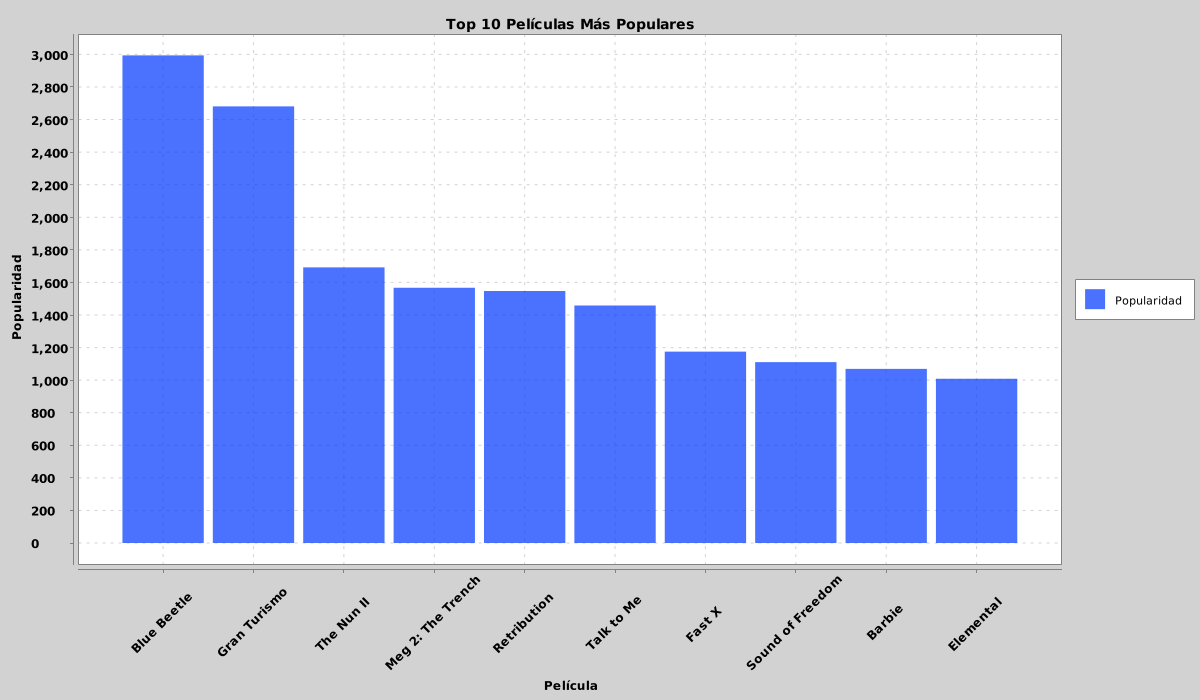

In [31]:
import tech.tablesaw.api.*;
import org.knowm.xchart.*;
import java.util.*;

// Leer CSV
Table peliculas = Table.read().csv("/workspaces/Ordenamiento-Manejo-de-colisiones-y-an-lisis-de-datos-en-Java/TMDB_100k.csv"); // Cambiar la ruta
peliculas = peliculas.dropRowsWithMissingValues();

// Top 10 por popularidad
Table top = peliculas.sortDescendingOn("popularity").first(10);

// Columnas
String[] titulos = top.textColumn("title").asObjectArray();

double[] popularidad = top.doubleColumn("popularity").asDoubleArray();

// Convertir arrays a listas
List<String> xData = Arrays.asList(titulos);

List<Double> yData = new ArrayList<>();

for (double p : popularidad) {
    yData.add(p);
}

// Crear gráfico
CategoryChart chart = new CategoryChartBuilder()
        .width(1200)
        .height(700)
        .title("Top 10 Películas Más Populares")
        .xAxisTitle("Película")
        .yAxisTitle("Popularidad")
        .build();
chart.getStyler().setXAxisLabelRotation(45);
// Agregar datos
chart.addSeries("Popularidad", xData, yData);

// Mostrar en Jupyter
BitmapEncoder.getBufferedImage(chart)

In [ ]:
Table peliculas = Table.read().csv("/workspaces/Ordenamiento-Manejo-de-colisiones-y-an-lisis-de-datos-en-Java/TMDB_100k.csv"); /*Cambiar el path */
Integer[] runtime = peliculas.intColumn("runtime").asObjectArray();

System.out.print(Arrays.toString(runtime))

[148, 169, 152, 162, 143, 108, 149, 139, 121, 154, 142, 152, 126, 165, 142, 181, 136, 194, 122, 179, 201, 138, 180, 141, 147, 165, 130, 135, 115, 121, 153, 142, 133, 161, 137, 179, 124, 123, 141, 115, 124, 140, 131, 95, 124, 127, 157, 143, 130, 121, 141, 96, 117, 175, 141, 116, 136, 148, 138, 153, 137, 100, 135, 101, 132, 146, 105, 136, 121, 98, 149, 169, 92, 81, 157, 152, 89, 155, 103, 115, 116, 133, 112, 136, 117, 120, 144, 111, 146, 113, 104, 113, 135, 189, 113, 100, 124, 90, 111, 129, 129, 102, 107, 109, 89, 127, 119, 125, 129, 151, 102, 116, 123, 112, 130, 101, 169, 124, 113, 195, 132, 129, 143, 91, 132, 140, 116, 141, 133, 152, 143, 95, 127, 117, 115, 107, 151, 100, 103, 113, 108, 111, 108, 132, 136, 126, 169, 144, 99, 188, 117, 129, 108, 137, 139, 91, 143, 136, 117, 92, 98, 114, 117, 119, 118, 140, 139, 122, 93, 119, 97, 116, 127, 108, 141, 164, 81, 142, 120, 161, 162, 116, 144, 120, 139, 133, 98, 118, 105, 122, 132, 137, 166, 108, 108, 137, 145, 100, 131, 137, 101, 114, 107, 14

In [33]:

// =======================
// MERGE SORT
// =======================

void mergeSort(Integer[] arr, int left, int right) {

    if (left < right) {

        int mid = (left + right) / 2;

        mergeSort(arr, left, mid);
        mergeSort(arr, mid + 1, right);

        merge(arr, left, mid, right);
    }
}

void merge(Integer[] arr, int left, int mid, int right) {

    int n1 = mid - left + 1;
    int n2 = right - mid;

    Integer[] L = new Integer[n1];
    Integer[] R = new Integer[n2];

    for (int i = 0; i < n1; i++) {
        L[i] = arr[left + i];
    }

    for (int j = 0; j < n2; j++) {
        R[j] = arr[mid + 1 + j];
    }

    int i = 0;
    int j = 0;
    int k = left;

    while (i < n1 && j < n2) {

        if (L[i] <= R[j]) {

            arr[k] = L[i];
            i++;

        } else {

            arr[k] = R[j];
            j++;
        }

        k++;
    }

    while (i < n1) {

        arr[k] = L[i];
        i++;
        k++;
    }

    while (j < n2) {

        arr[k] = R[j];
        j++;
        k++;
    }
}

// =======================
// LEER CSV
// =======================

Table peliculas = Table.read().csv("/workspaces/Ordenamiento-Manejo-de-colisiones-y-an-lisis-de-datos-en-Java/TMDB_100k.csv");

Integer[] runtime = peliculas.intColumn("runtime").asObjectArray();

// Ordenar
mergeSort(runtime, 0, runtime.length - 1);

// Mostrar
System.out.println(Arrays.toString(runtime));

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 